# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.snowball import SnowballStemmer

nltk.download('stopwords')
nltk.download('punkt_tab')

In [ ]:
raw_df = pd.read_csv('drive/MyDrive/Colab Notebooks/data/tweet_sentiment_train.csv.zip')
raw_df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [ ]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [ ]:
raw_df.shape

(27481, 4)

In [ ]:
raw_df.describe()

,textID,text,selected_text,sentiment
count,27481,27480,27480,27481
unique,27481,27480,22463,3
top,6f7127d9d7,All this flirting going on - The ATG smiles...,good,neutral
freq,1,1,199,11118


In [ ]:
raw_df.isnull().sum()[raw_df.isnull().sum() > 0]

,0
text,1
selected_text,1


In [ ]:
raw_df[raw_df['text'].isna()]

,textID,text,selected_text,sentiment
314,fdb77c3752,NaN,NaN,neutral


We have only 1 raw with missing values, so we can delete it.

In [ ]:
raw_df.dropna(inplace=True, ignore_index=True)

In [ ]:
raw_df.shape

(27480, 4)

### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [ ]:
raw_df.sentiment.value_counts(normalize=True).round(2)

,proportion
sentiment,
neutral,0.40
positive,0.31
negative,0.28


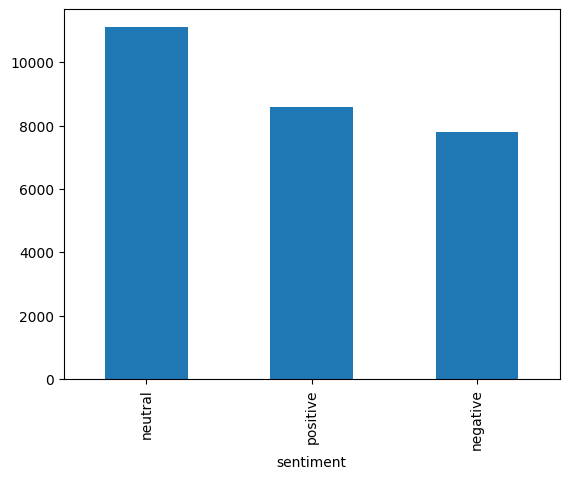

In [ ]:
raw_df.sentiment.value_counts().plot.bar();

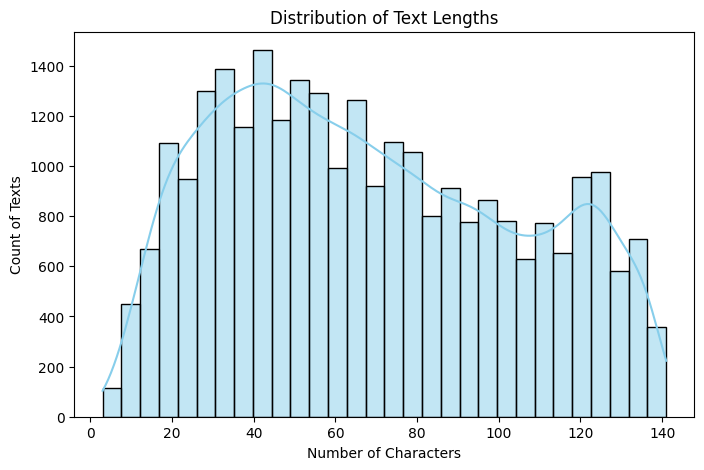

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(raw_df['text'].str.len(), bins=30, kde=True, color='skyblue')
plt.title('Distribution of Text Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Count of Texts')
plt.show()

In [ ]:
raw_df['text'].str.len().describe()

,text
count,27480.000000
mean,68.330022
std,35.603870
min,3.000000
25%,39.000000
50%,64.000000
75%,97.000000
max,141.000000


* On average, users write short texts (mean = 68 characters)
* There’s quite a bit of variation in length — some users write very short, some quite long texts (std = 35.6)
* 25% = 39, 50% = 64, 75% = 97	   
Half of all posts are shorter than 64 characters, and 75% are under 100 characters

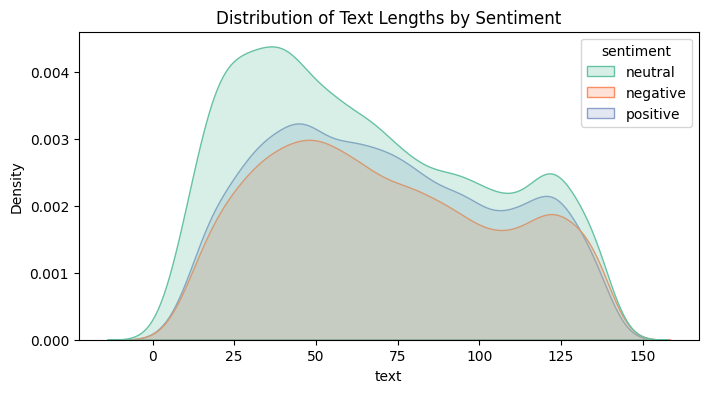

In [ ]:
plt.figure(figsize=(8,4))
sns.kdeplot(
    data=raw_df,
    x=raw_df['text'].str.len(),
    hue='sentiment',
    fill=True,
    palette='Set2'
)
plt.title('Distribution of Text Lengths by Sentiment')
plt.show()

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [ ]:
stemmer = SnowballStemmer(language='english')
english_stopwords = stopwords.words('english')

In [ ]:
", ".join(english_stopwords)

"a, about, above, after, again, against, ain, all, am, an, and, any, are, aren, aren't, as, at, be, because, been, before, being, below, between, both, but, by, can, couldn, couldn't, d, did, didn, didn't, do, does, doesn, doesn't, doing, don, don't, down, during, each, few, for, from, further, had, hadn, hadn't, has, hasn, hasn't, have, haven, haven't, having, he, he'd, he'll, her, here, hers, herself, he's, him, himself, his, how, i, i'd, if, i'll, i'm, in, into, is, isn, isn't, it, it'd, it'll, it's, its, itself, i've, just, ll, m, ma, me, mightn, mightn't, more, most, mustn, mustn't, my, myself, needn, needn't, no, nor, not, now, o, of, off, on, once, only, or, other, our, ours, ourselves, out, over, own, re, s, same, shan, shan't, she, she'd, she'll, she's, should, shouldn, shouldn't, should've, so, some, such, t, than, that, that'll, the, their, theirs, them, themselves, then, there, these, they, they'd, they'll, they're, they've, this, those, through, to, too, under, until, up, 

In [ ]:
def tokenize(text):
    return [stemmer.stem(word) for word in word_tokenize(text)]

In [ ]:
vectorizer = CountVectorizer(
    lowercase=True,
    tokenizer=tokenize,
    stop_words=english_stopwords,
    max_features=1500
)

In [ ]:
vectorizer.fit(raw_df.text)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'m", "'s", 'abov', 'ani', 'becaus', 'befor', 'could', 'doe', 'dure', 'might', 'must', "n't", 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(


CountVectorizer(max_features=1500,
                stop_words=['a', 'about', 'above', 'after', 'again', 'against',
                            'ain', 'all', 'am', 'an', 'and', 'any', 'are',
                            'aren', "aren't", 'as', 'at', 'be', 'because',
                            'been', 'before', 'being', 'below', 'between',
                            'both', 'but', 'by', 'can', 'couldn', "couldn't", ...],
                tokenizer=<function tokenize at 0x7a9ee05dd4e0>)

In [ ]:
len(vectorizer.vocabulary_)

1500

In [ ]:
vectorizer.get_feature_names_out()[:100]

array(['!', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '--',
       '.', '..', '...', '....', '.....', '......', '.......', '/', '1',
       '10', '100', '11', '12', '13', '14', '15', '17', '1st', '2', '20',
       '24', '25', '2day', '2nd', '2nite', '3', '30', '3d', '3rd', '4',
       '40', '4th', '5', '50', '6', '7', '8', '80', '9', ':', ';', '<',
       '=', '>', '?', '@', '[', ']', '_', '`', 'abl', 'absolut', 'abt',
       'accept', 'access', 'accid', 'account', 'ace', 'ach', 'across',
       'act', 'action', 'actual', 'ad', 'add', 'addict', 'admit', 'ador',
       'afford', 'afraid', 'afternoon', 'age', 'ago', 'agre', 'ah', 'aha',
       'ahead', 'ahh', 'ahhh', 'ahhhh', 'aint', 'air', 'airport', 'alarm',
       'album', 'allergi', 'allow'], dtype=object)

In [ ]:
vectorizer.get_feature_names_out()[-100:]

array(['version', 'via', 'vid', 'video', 'view', 'visit', 'voic', 'vote',
       'w', 'w/', 'wait', 'waitin', 'wake', 'walk', 'wall', 'wan', 'want',
       'war', 'warm', 'wash', 'wasnt', 'wast', 'wat', 'watch', 'watchin',
       'water', 'wave', 'way', 'wear', 'weather', 'web', 'websit', 'wed',
       'wednesday', 'wee', 'week', 'weekend', 'weird', 'welcom', 'well',
       'went', 'whatev', 'whi', 'white', 'whole', 'wide', 'wife', 'wild',
       'win', 'wind', 'window', 'wine', 'winter', 'wish', 'wit',
       'without', 'woke', 'wolverin', 'woman', 'women', 'wonder', 'wont',
       'woo', 'woot', 'word', 'work', 'workin', 'world', 'worri', 'wors',
       'worst', 'worth', 'would', 'wow', 'write', 'wrong', 'wtf', 'x',
       'xd', 'xoxo', 'ya', 'yall', 'yay', 'yea', 'yeah', 'year', 'yep',
       'yes', 'yesterday', 'yet', 'yo', 'young', 'youtub', 'yr', 'yum',
       'yummi', 'yup', '|', '~', 'ï¿½'], dtype=object)

In [ ]:
inputs = vectorizer.transform(raw_df.text)
inputs.shape

(27480, 1500)

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [ ]:
train_idx, test_idx = train_test_split(
    raw_df.index,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=raw_df['sentiment']
)

X_train_bow, X_test_bow = inputs[train_idx], inputs[test_idx]
y_train, y_test = raw_df.loc[train_idx, 'sentiment'], raw_df.loc[test_idx, 'sentiment']

In [ ]:
def validate_model(model, x_train, y_train):
  model.fit(x_train, y_train)
  train_preds = model.predict(x_train)
  print(f'Accuracy: {accuracy_score(y_train, train_preds):.4f}')
  print(f'F1 Score: {f1_score(y_train, train_preds, average="weighted"):.4f}')

Logistic Regression

In [ ]:
MAX_ITER = 2000
log_reg = LogisticRegression(max_iter=MAX_ITER, solver='sag')
validate_model(log_reg, X_train_bow, y_train)

Accuracy: 0.7600
F1 Score: 0.7599


Decision Tree

In [ ]:
dec_tree = DecisionTreeClassifier(random_state=42)
validate_model(dec_tree, X_train_bow, y_train)

Accuracy: 0.9926
F1 Score: 0.9926


Random Forest

In [ ]:
rnd_tree = RandomForestClassifier(max_depth=50, random_state=42)
validate_model(rnd_tree, X_train_bow, y_train)

Accuracy: 0.8189
F1 Score: 0.8174


XGBoost

In [ ]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

In [ ]:
for max_depth in [10, 20, 30]:
  print(f"max_depth = {max_depth}")
  xgb_clf = XGBClassifier(max_depth=max_depth, random_state=42)
  validate_model(xgb_clf, X_train_bow, y_train_enc)
  print()

max_depth = 10
Accuracy: 0.8146
F1 Score: 0.8141

max_depth = 20
Accuracy: 0.8913
F1 Score: 0.8913

max_depth = 30
Accuracy: 0.9280
F1 Score: 0.9282



LightGBM

In [ ]:
X_train_bow_int = X_train_bow.astype(np.float32)

In [ ]:
lgb_clf = LGBMClassifier(
    max_depth=5,
    n_estimators=50,
    random_state=42,
    verbosity=-1,
)
validate_model(lgb_clf, X_train_bow_int, y_train_enc)

Accuracy: 0.6630
F1 Score: 0.6573


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


`DecisionTreeClassifier` and `XGBClassifier` showed the best results. Let's compare them.

Decision Tree

In [ ]:
dct_train_pred = dec_tree.predict(X_train_bow)
dct_test_pred = dec_tree.predict(X_test_bow)

print(classification_report(y_train, dct_train_pred, digits=4))
print(classification_report(y_test, dct_test_pred, digits=4))

              precision    recall  f1-score   support

    negative     0.9932    0.9923    0.9928      6225
     neutral     0.9881    0.9952    0.9916      8894
    positive     0.9981    0.9897    0.9939      6865

    accuracy                         0.9926     21984
   macro avg     0.9931    0.9924    0.9927     21984
weighted avg     0.9927    0.9926    0.9926     21984

              precision    recall  f1-score   support

    negative     0.5634    0.5855    0.5742      1556
     neutral     0.6025    0.5897    0.5960      2223
    positive     0.6788    0.6733    0.6760      1717

    accuracy                         0.6146      5496
   macro avg     0.6149    0.6162    0.6154      5496
weighted avg     0.6153    0.6146    0.6149      5496



XGBoost

In [ ]:
xgb_clf = XGBClassifier(max_depth=30, random_state=42)
xgb_clf.fit(X_train_bow, y_train_enc)

xgb_train_pred = xgb_clf.predict(X_train_bow)
xgb_test_pred = xgb_clf.predict(X_test_bow)

print(classification_report(y_train_enc, xgb_train_pred, digits=4))
print(classification_report(y_test_enc, xgb_test_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9728    0.8745    0.9211      6225
           1     0.8730    0.9812    0.9240      8894
           2     0.9748    0.9076    0.9400      6865

    accuracy                         0.9280     21984
   macro avg     0.9402    0.9211    0.9284     21984
weighted avg     0.9331    0.9280    0.9282     21984

              precision    recall  f1-score   support

           0     0.7098    0.6163    0.6598      1556
           1     0.6450    0.7314    0.6855      2223
           2     0.7605    0.7193    0.7393      1717

    accuracy                         0.6951      5496
   macro avg     0.7051    0.6890    0.6949      5496
weighted avg     0.6994    0.6951    0.6950      5496



Despite the fact that `DecisionTreeClassifier` showed better results on train data, it was not so accurate with test data as `XGBClassifier`.

In [ ]:
def show_conf_matrix(y_input, pred):
  confusion_matrix_ = confusion_matrix(y_input, pred, normalize='true')
  plt.figure()
  sns.heatmap(confusion_matrix_, annot=True, cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, fmt='.2f')
  plt.xlabel('Prediction')
  plt.ylabel('Target')
  plt.title('Confusion Matrix')
  plt.show();

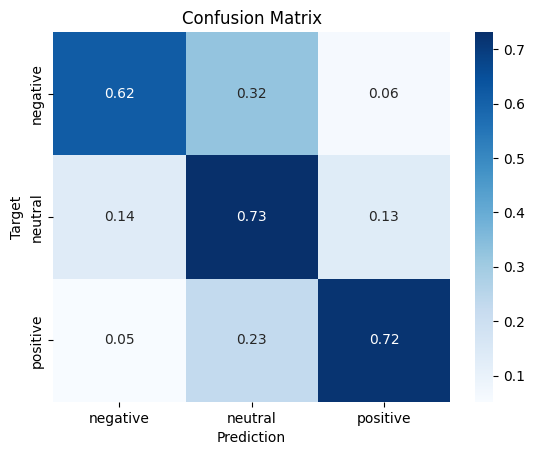

In [ ]:
show_conf_matrix(y_test_enc, xgb_test_pred)

The `XGBoost` model shows solid and balanced multiclass performance:   
* The model correctly predicts the majority of examples in all three classes.
* The model performs best on neutral and positive texts (≈ 73% and 72% correctly classified).

Common confusions:    
Negative → Neutral (32%)
The model often misclassifies slightly negative texts as neutral.

Positive → Neutral (23%)
Also, some positive posts are interpreted as neutral — perhaps due to weakly positive words or lack of clear emotion.


### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [ ]:
feature_importance = pd.Series(xgb_clf.feature_importances_, index=vectorizer.get_feature_names_out(), name='importance').sort_values(ascending=False)
feature_importance[:10]

,importance
thank,0.011935
happi,0.008050
sad,0.007288
hurt,0.007180
hate,0.006669
amaz,0.005865
love,0.005609
bore,0.005470
fail,0.005383
awesom,0.005110


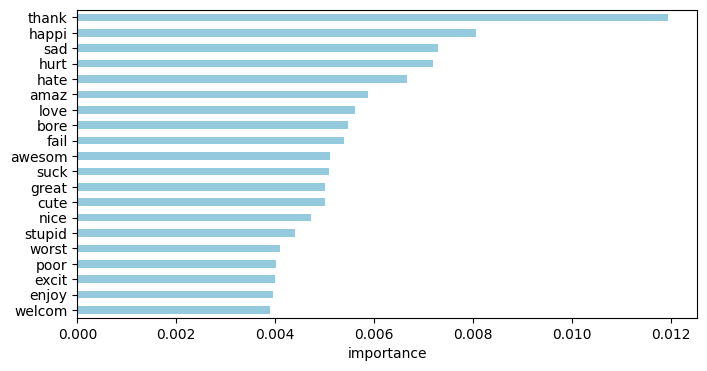

In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(feature_importance[:20], orient='h', color='skyblue', width=0.5)
plt.show()

In [ ]:
feature_importance[-10:]

,importance
absolut,0.0
cd,0.0
13,0.0
wasnt,0.0
.......,0.0
12,0.0
......,0.0
2nite,0.0
25,0.0
24,0.0


The model correctly focuses on emotionally charged words that clearly express gratitude, happiness, or frustration, while ignoring neutral or contextless terms.
* All are positive emotion words showing that the model strongly associates them with positive class (happi, amaz, love, awesom, great, nice, cute, excit, welcom).
* Negative emotion or failure words are key indicators of negative sentiment (sad, hate, hurt, fail, bore, suck, worst, stupid, sick, poor).

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vectorizer_tfidf = TfidfVectorizer(
    lowercase=True,
    tokenizer=tokenize,
    stop_words=english_stopwords,
    max_features=1500
)

vectorizer_tfidf.fit(raw_df.text)

inputs_tfidf = vectorizer_tfidf.transform(raw_df.text)
inputs_tfidf.shape

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'m", "'s", 'abov', 'ani', 'becaus', 'befor', 'could', 'doe', 'dure', 'might', 'must', "n't", 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(


(27480, 1500)

In [ ]:
X_train_bow_tfidf, X_test_bow_tfidf = inputs_tfidf[train_idx], inputs_tfidf[test_idx]

In [ ]:
xgb_clf_tfidf = XGBClassifier(max_depth=30, random_state=42)
validate_model(xgb_clf_tfidf, X_train_bow_tfidf, y_train_enc)

Accuracy: 0.9528
F1 Score: 0.9530


In [ ]:
xgb_train_pred_tfidf = xgb_clf_tfidf.predict(X_train_bow_tfidf)
xgb_test_pred_tfidf = xgb_clf_tfidf.predict(X_test_bow_tfidf)

print(classification_report(y_train_enc, xgb_train_pred_tfidf, digits=4))
print(classification_report(y_test_enc, xgb_test_pred_tfidf, digits=4))

              precision    recall  f1-score   support

           0     0.9877    0.9160    0.9505      6225
           1     0.9072    0.9935    0.9484      8894
           2     0.9904    0.9336    0.9612      6865

    accuracy                         0.9528     21984
   macro avg     0.9618    0.9477    0.9533     21984
weighted avg     0.9560    0.9528    0.9530     21984

              precision    recall  f1-score   support

           0     0.7054    0.6080    0.6531      1556
           1     0.6308    0.7179    0.6716      2223
           2     0.7545    0.7140    0.7337      1717

    accuracy                         0.6856      5496
   macro avg     0.6969    0.6800    0.6861      5496
weighted avg     0.6906    0.6856    0.6857      5496



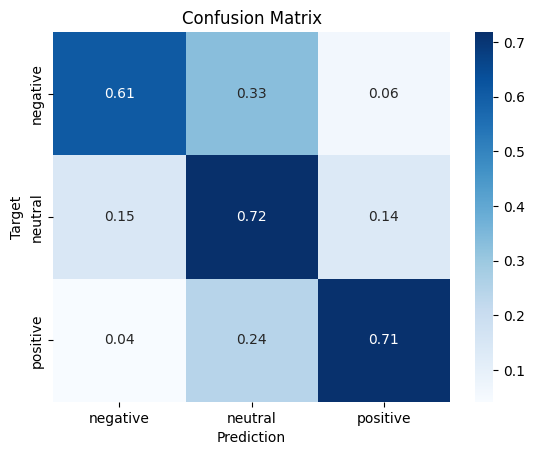

In [ ]:
show_conf_matrix(y_test_enc, xgb_test_pred_tfidf)

`TF-IDF` method showed better results on train data, but it showed less accurate results with test data.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
test_pred_df = raw_df.loc[test_idx].copy().drop(columns=['textID', 'selected_text'])
test_pred_df['predicted'] = le.inverse_transform(xgb_test_pred_tfidf)
errors = test_pred_df[test_pred_df['sentiment'] != test_pred_df['predicted']]

In [ ]:
errors

,text,sentiment,predicted
23413,Reading and taking notes but undertanding none of it ... HELP!,negative,neutral
4126,Hoping that this will just heal on it`s own because anything I put on it just makes it worse. Owww,neutral,positive
4831,yum. Do you do home delivery,positive,neutral
19359,Having a wonderful piece of cake for lunch - what else could I want???,positive,neutral
17483,"Awww, *hugs* I wish I could help.",negative,positive
...,...,...,...
16012,"I think he thought about it, but then I sneezed on him",negative,neutral
11897,That is messed up. I hope your day gets better.,neutral,positive
16888,Chilling with Colton who just redesigned the Cocktail Hacker card backs for me.,positive,neutral
18662,"Just eaten, and feel extremely bloated... now for the not so fun part.",negative,positive


In [ ]:

errors[['sentiment', 'predicted']].value_counts().sort_values(ascending=False)

sentiment  predicted
negative   neutral      515
positive   neutral      419
neutral    negative     323
           positive     304
negative   positive      95
positive   negative      72
Name: count, dtype: int64

The model frequently classifies both negative and positive texts as neutral.
It tends to be too conservative — it prefers to call something neutral rather than risk labeling it as strongly positive or negative.

Happens when:

* The emotional words are weak (“a bit sad”, “pretty good”)

* The text contains mixed tone or lacks clear emotion

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model

In [ ]:
!pip install transformers datasets evaluate torch --quiet

In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
import evaluate

dataset = Dataset.from_pandas(raw_df[["text", "sentiment"]].rename(columns={"sentiment": "label"}))
dataset = dataset.class_encode_column("label")

# tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=256)

tokenized = dataset.map(tokenize, batched=True)


# stratified split
tokenized = tokenized.train_test_split(test_size=0.2, stratify_by_column="label", seed=42)

# metrics
metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": metric_acc.compute(predictions=preds, references=labels)["accuracy"],
        "f1": metric_f1.compute(predictions=preds, references=labels, average="weighted")["f1"],
    }

num_labels = tokenized["train"].features["label"].num_classes

# model + training
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels
)

args = TrainingArguments(
    output_dir="./bert_cls",
    learning_rate=2e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    logging_strategy="epoch",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()
metrics = trainer.evaluate()
print(metrics)

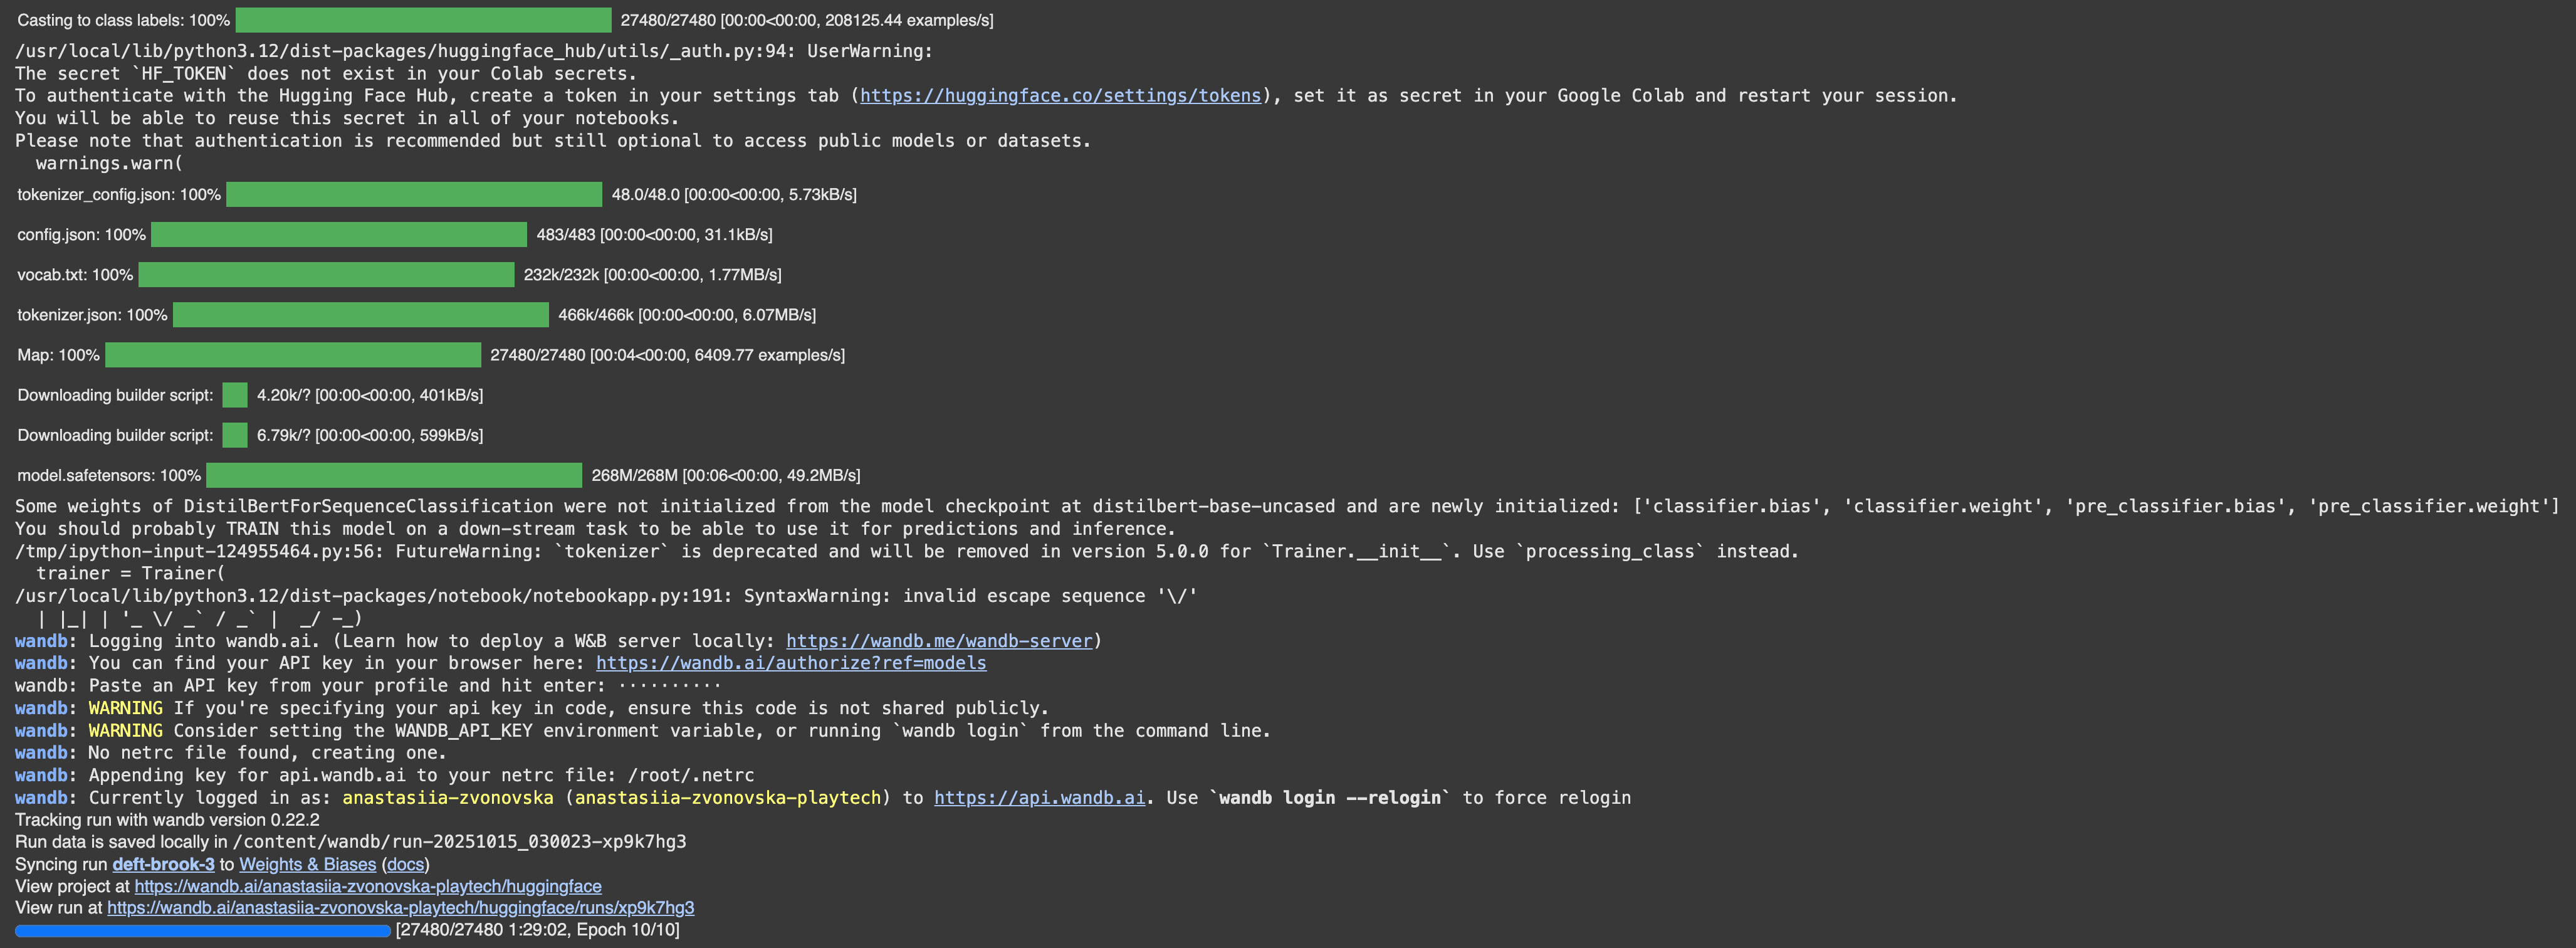

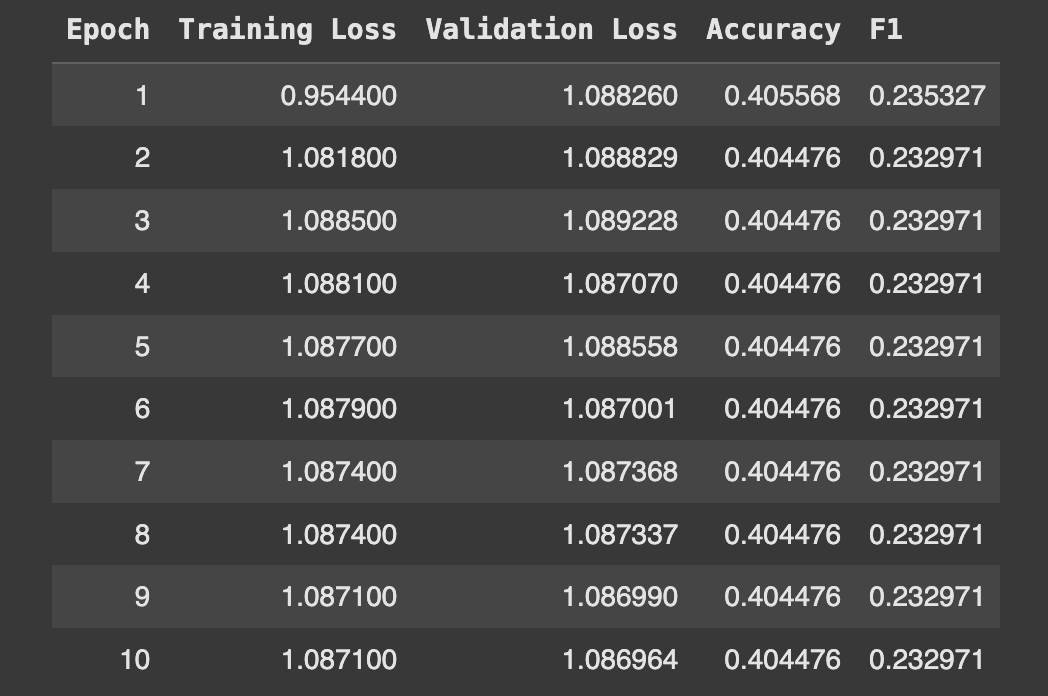